# Tabular foundation models vs gradient boosting: a hands-on tour

Every problem gets an LLM thrown at it now, and lately that includes predicting the
number in a spreadsheet. A new class of model, the *tabular foundation model*, promises
to skip the whole build-a-model step: no feature engineering, no training run, no
tuning. Hand over the table and predictions come back.

For twenty years the default answer to a tabular problem has been a gradient-boosted
tree. **So does the foundation model actually replace the tree?** This notebook runs the
comparison on real data so you can watch the answer appear.

It calls the repo's own code, so nothing here is a toy reimplementation. The full study,
every number, and the write-up are in the [README](../README.md) and
[FINDINGS.md](../FINDINGS.md).

> **How this notebook is wired.** The classical models run live in a few seconds. The
> foundation models are heavy (TabFM is a six-hour CPU job, and torch and FAISS deadlock
> against a notebook kernel), so their measured results are read from `results/probe/`
> rather than re-run here. To regenerate those from scratch, use `scripts/sweep.py`.

In [1]:
import sys, json, warnings
from pathlib import Path
import numpy as np, pandas as pd
from sklearn.metrics import roc_auc_score

# Find the repo (the folder holding scripts/prep.py) and import its code.
here = Path.cwd()
repo = next(p for p in [here, *here.parents] if (p / "scripts" / "prep.py").exists())
sys.path.insert(0, str(repo / "scripts"))

from prep import load_split, as_categorical, encode_for_gbdt
import run_one as ro
from showdown import paired

warnings.filterwarnings("ignore")
print("repo:", repo.name)

repo: tabular-fm-scorecard


## 1. Load a real dataset

`load_split` returns a stratified train/test split of one of the four OpenML datasets.
`n_context` is the number of rows the model trains on. For an in-context foundation
model that number *is* the context window, which is why the study sweeps it rather than
fixing it. We start with German credit risk.

In [2]:
Xtr, ytr, Xte, yte = load_split("credit_g", n_context=700, n_test=300)
print(f"train: {len(ytr)} rows   test: {len(yte)} rows   positive rate: {yte.mean():.1%}")
Xtr.head(3)

train: 700 rows   test: 300 rows   positive rate: 30.0%


,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,residence_since,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker
0,0<=X<200,12,existing paid,radio/tv,1331.0,<100,<1,2,male single,none,1,car,22,stores,own,1,skilled,1,none,yes
1,no checking,10,existing paid,new car,1309.0,no known savings,1<=X<4,4,male single,guarantor,4,life insurance,27,none,own,1,unskilled resident,1,none,yes
2,>=200,18,existing paid,furniture/equipment,3049.0,<100,<1,1,female div/dep/mar,none,1,life insurance,45,stores,own,1,unskilled resident,1,none,yes


## 2. Run a model yourself

Each model gets the data in the form it wants: the trees get real categorical columns,
the linear baseline gets a numeric matrix. The helper below reuses the exact dispatch
from `run_one.py`, so a model is driven the same way the benchmark drives it. Here we
fit two classical models live and score them on the held-out rows.

In [3]:
def evaluate(key, Xtr, ytr, Xte, yte):
    """Fit and score one model, giving it the frame the benchmark uses."""
    kind = ro.frame_kind(key)                     # 'category', 'numeric', or 'raw'
    if kind == "category":
        a, b, cat_cols = as_categorical(Xtr, Xte)
        proba, t_fit, t_pred, _ = ro.RUNNERS[key](a, ytr, b, cat_cols)
    else:
        a, b = (encode_for_gbdt(Xtr, Xte) if kind == "numeric" else (Xtr, Xte))
        proba, t_fit, t_pred, _ = ro.RUNNERS[key](a, ytr, b)
    return proba, roc_auc_score(yte, proba)

for m in ["logreg", "xgboost", "lightgbm", "catboost"]:
    _, auc = evaluate(m, Xtr, ytr, Xte, yte)
    print(f"{m:10s} ROC AUC = {auc:.4f}")

logreg     ROC AUC = 0.6633


xgboost    ROC AUC = 0.7413


lightgbm   ROC AUC = 0.7226


catboost   ROC AUC = 0.7277


That is the whole classical pipeline, live. The foundation models fit the same way
(`fit` on the training rows, then `predict_proba`), but they are slow and heavy to run
in a notebook, so we read their measured results next instead of re-running them.

## 3. The full comparison, from the committed sweep

Every model in the study was run on identical splits with prediction cost logged
alongside accuracy. We load those committed results for `credit_g` and put accuracy next
to cost, the column most model comparisons never show.

In [4]:
def score_1m(seconds_per_1k):
    s = seconds_per_1k * 1000            # 1,000,000 rows / 1,000
    if s < 90:      return f"{s:.1f} s"
    if s < 5400:    return f"{s/60:.1f} min"
    if s < 172800:  return f"{s/3600:.1f} h"
    return f"{s/86400:.1f} days"

FMS = {"tabfm", "tabicl", "tabdpt"}
def probe(dataset, model, n):
    d = json.loads((repo / "results" / "probe" / f"{dataset}__{model}__c{n}.json").read_text())
    return {"model": model,
            "family": "foundation model" if model in FMS else "classical",
            "AUC": round(d["auc"], 4),
            "predict s / 1k": d["predict_seconds_per_1k"],
            "score 1M rows": score_1m(d["predict_seconds_per_1k"])}

order = ["tabfm", "tabicl", "tabdpt", "xgboost", "lightgbm", "catboost", "logreg"]
table = pd.DataFrame([probe("credit_g", m, 700) for m in order]).sort_values("AUC", ascending=False)
table.reset_index(drop=True)

,model,family,AUC,predict s / 1k,score 1M rows
0,tabdpt,foundation model,0.7779,0.6331,10.6 min
1,tabfm,foundation model,0.7666,5459.3300,63.2 days
2,tabicl,foundation model,0.7614,5.5714,1.5 h
3,xgboost,classical,0.7413,0.0219,21.9 s
4,catboost,classical,0.7277,0.0065,6.5 s
5,lightgbm,classical,0.7226,0.0156,15.6 s
6,logreg,classical,0.6633,0.0015,1.5 s


The accuracy spread is small. The cost spread runs across orders of magnitude, from
a fraction of a second to score a million customers with the classical tooling to days
with the foundation model. The chart makes that concrete.

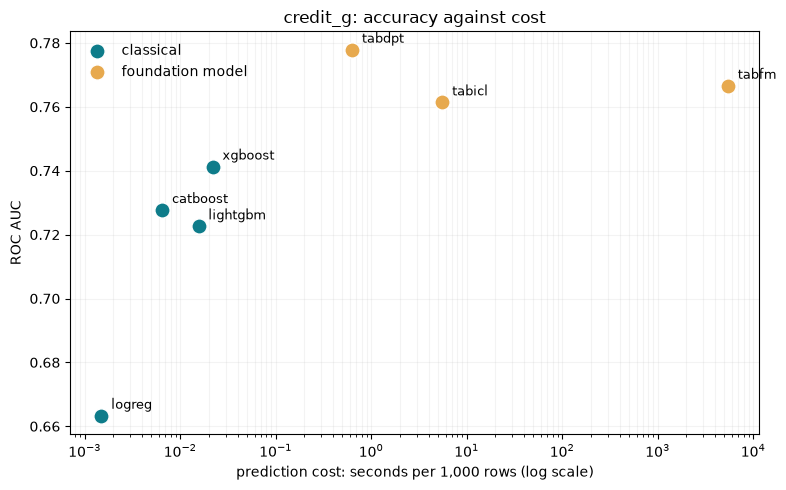

In [5]:
import matplotlib.pyplot as plt
colors = {"classical": "#0E7C8A", "foundation model": "#E7A94E"}
fig, ax = plt.subplots(figsize=(8, 5))
for fam, sub in table.groupby("family"):
    ax.scatter(sub["predict s / 1k"], sub["AUC"], s=120, color=colors[fam],
               label=fam, zorder=3, edgecolor="white", linewidth=1)
    for _, r in sub.iterrows():
        ax.annotate(r["model"], (r["predict s / 1k"], r["AUC"]),
                    textcoords="offset points", xytext=(7, 5), fontsize=9)
ax.set_xscale("log")
ax.set_xlabel("prediction cost: seconds per 1,000 rows (log scale)")
ax.set_ylabel("ROC AUC")
ax.set_title("credit_g: accuracy against cost")
ax.grid(True, which="both", alpha=0.15)
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

## 4. The catch: give the tree its full data

The comparison above capped every model at the small training set a foundation model can
afford. A tree has no such cap in production. So the study ran the same LightGBM again on
**every** row each dataset has, scored on the **identical** test rows, and compared it to
TabFM with a paired bootstrap.

Here we load those committed prediction vectors and run the same `paired` bootstrap
ourselves. Read the result like an election poll: when the interval on the gap crosses
zero, the lead is inside the margin of error, and it is a tie.

In [6]:
pairs = [
    ("German credit",     "credit_g__tabfm__c700.npz",       "credit_g__lightgbm_full__c700.npz"),
    ("FICO home equity",  "heloc__tabfm__c1000.npz",         "heloc__lightgbm_full__c9459.npz"),
    ("Bank marketing",    "bank_marketing__tabfm__c1000.npz","bank_marketing__lightgbm_full__c44211.npz"),
    ("Telecom appetency", "kdd_appetency__tabfm__c1000.npz", "kdd_appetency__lightgbm_full__c47000.npz"),
]
def load_npz(name):
    d = np.load(repo / "results" / "probe" / name)
    return d["y_true"], d["proba"]

rows = []
for label, fm_file, tree_file in pairs:
    y, fm_proba = load_npz(fm_file)
    y2, tree_proba = load_npz(tree_file)
    assert np.array_equal(y, y2), "test rows must match"
    r = paired(y, fm_proba, tree_proba)             # gap = TabFM minus tree, with 95% CI
    rows.append({"dataset": label, "gap (TabFM - tree)": f"{r['delta']:+.4f}",
                 "95% interval": f"[{r['ci_lo']:+.4f}, {r['ci_hi']:+.4f}]",
                 "p": r["p"],
                 "verdict": "tie" if r["ci_lo"] <= 0 <= r["ci_hi"] else "separated"})
pd.DataFrame(rows)

,dataset,gap (TabFM - tree),95% interval,p,verdict
0,German credit,+0.0440,"[-0.0000, +0.0870]",0.0504,tie
1,FICO home equity,+0.0098,"[-0.0039, +0.0235]",0.1632,tie
2,Bank marketing,+0.0000,"[-0.0076, +0.0077]",0.9964,tie
3,Telecom appetency,-0.0578,"[-0.1315, +0.0079]",0.0868,tie


**Four datasets, four ties.** Once the tree has the data it would actually have in
production, none of the gaps clears its own margin of error, and on bank marketing the
two scores are identical to the limit of floating point.

## What this means

- **Quality:** a draw, once the tree is given the data it would actually have.
- **Time:** the foundation model genuinely wins here. There is nothing to tune, retrain,
  or maintain.
- **Cost:** the foundation model loses by orders of magnitude at prediction time, which
  is the axis the chart above makes concrete.

Treat today's tabular foundation models as a prototyping accelerator, not a production
system, and check the licence before you benchmark: TabFM's weights are non-commercial.
The field moves fast, so revisit as the tools improve. The full method and reasoning are
in [FINDINGS.md](../FINDINGS.md).

To reproduce everything from scratch, including the slow foundation-model runs:

```bash
python scripts/sweep.py --models logreg,xgboost,lightgbm,catboost,tabicl,tabdpt
python scripts/compare.py && python scripts/verify_readme_claims.py
```